In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from datetime import timedelta
from netCDF4 import Dataset, date2num, num2date
import cftime
import glob
import os
import csv
%matplotlib inline
import datetime
from datetime import datetime
import matplotlib.dates as mdates
import matplotlib.dates as md
import metpy.calc as mpcalc
from metpy.units import units
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator



In [9]:
#read in file 
df= pd.read_csv('soilvue_data_061826.dat', header = 1, skiprows = [2,3], na_values=['NAN', 'NaN', 'nan', 'NAN '], keep_default_na = True)

#some NAN's, so I clean it here
cleaned_df = df.dropna()
cleaned_df['TIMESTAMP'] = pd.to_datetime(cleaned_df['TIMESTAMP'])
time = cleaned_df['TIMESTAMP']
cleaned_df

,TIMESTAMP,RECORD,BattV,PTemp_C,VWC_5cm,Ka_5cm,T_5cm,BulkEC_5cm,VWC_10cm,Ka_10cm,...,T_60cm,BulkEC_60cm,VWC_75cm,Ka_75cm,T_75cm,BulkEC_75cm,VWC_100cm,Ka_100cm,T_100cm,BulkEC_100cm
0,2026-06-16 15:18:00,1162,13.65,0,0.346,21.06,18.24,0.145,0.214,11.71,...,19.23,0.336,0.461,31.31,18.56,0.451,0.488,33.98,17.28,0.633
1,2026-06-16 15:19:00,1163,13.65,0,0.346,21.06,18.24,0.145,0.214,11.71,...,19.23,0.336,0.461,31.31,18.56,0.451,0.488,33.98,17.28,0.633
2,2026-06-16 15:20:00,1164,13.66,0,0.346,21.06,18.24,0.145,0.214,11.71,...,19.23,0.336,0.461,31.31,18.56,0.451,0.488,33.98,17.28,0.633
3,2026-06-16 15:21:00,1165,13.66,0,0.346,21.06,18.24,0.145,0.214,11.71,...,19.23,0.336,0.461,31.31,18.56,0.451,0.488,33.98,17.28,0.633
4,2026-06-16 15:22:00,1166,13.62,0,0.346,21.06,18.24,0.145,0.214,11.71,...,19.23,0.336,0.461,31.31,18.56,0.451,0.488,33.98,17.28,0.633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3255,2026-06-18 21:33:00,4417,13.55,0,0.395,25.20,25.12,0.175,0.232,12.83,...,17.93,0.332,0.457,30.91,17.77,0.453,0.485,33.67,17.00,0.640
3256,2026-06-18 21:34:00,4418,13.55,0,0.395,25.20,25.12,0.175,0.232,12.83,...,17.93,0.332,0.457,30.91,17.77,0.453,0.485,33.67,17.00,0.640
3257,2026-06-18 21:35:00,4419,13.55,0,0.395,25.20,25.12,0.175,0.232,12.83,...,17.93,0.332,0.457,30.91,17.77,0.453,0.485,33.67,17.00,0.640
3258,2026-06-18 21:36:00,4420,13.55,0,0.395,25.20,25.12,0.175,0.232,12.83,...,17.93,0.332,0.457,30.91,17.77,0.453,0.485,33.67,17.00,0.640


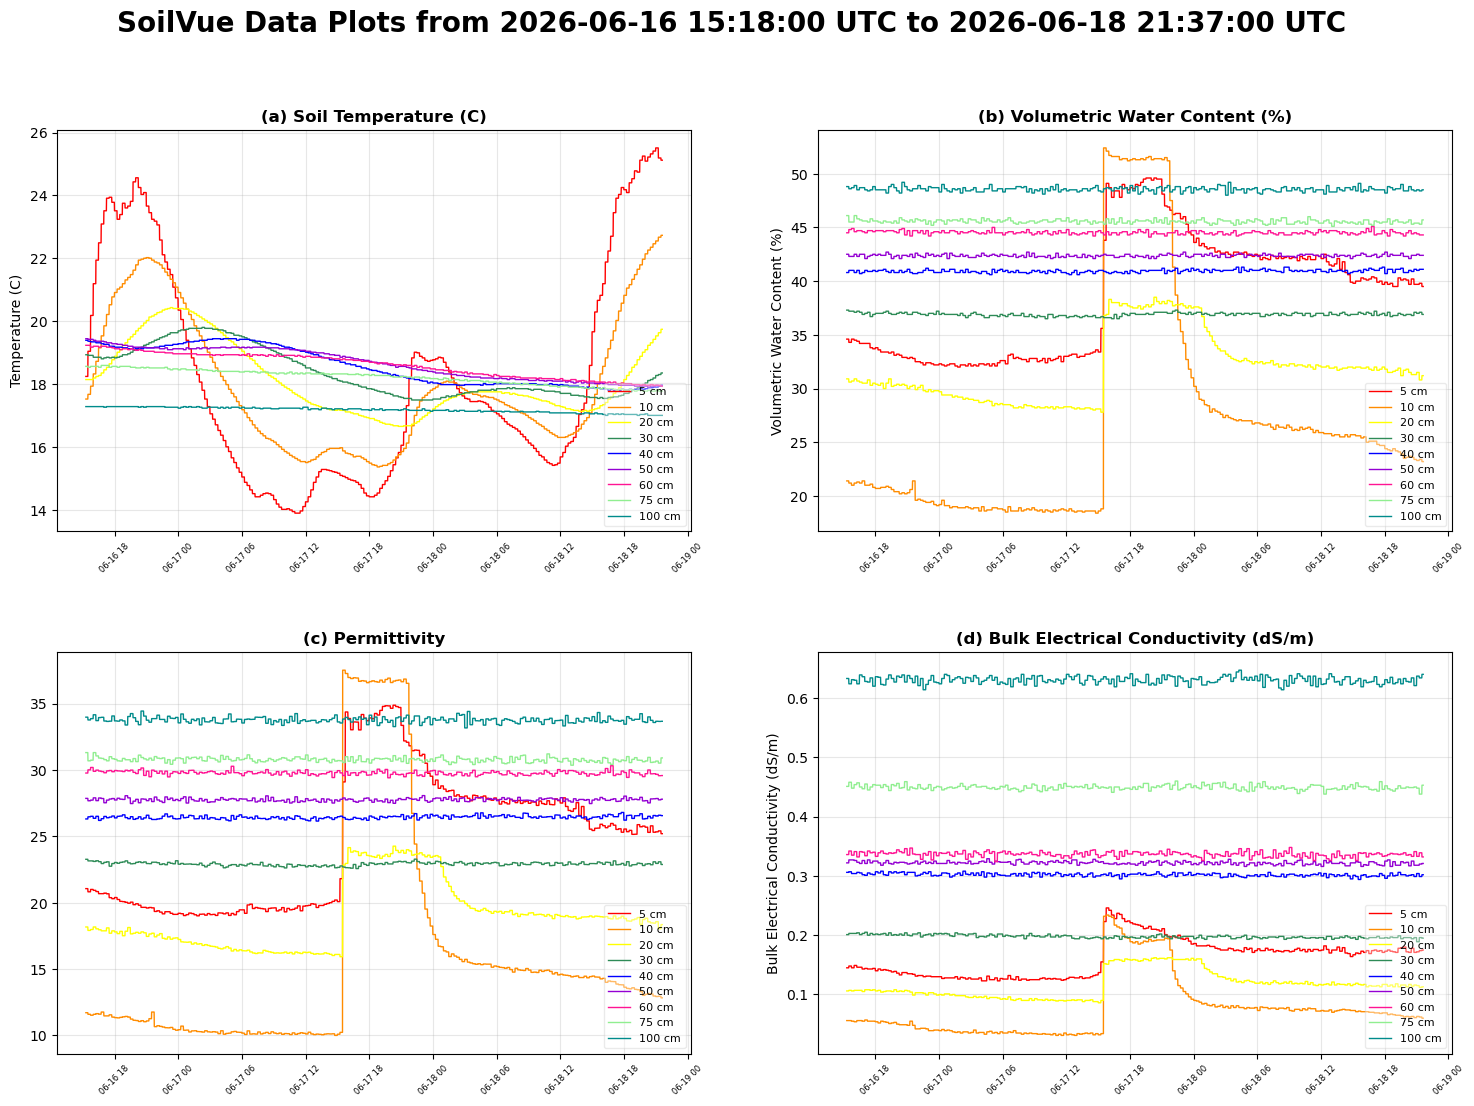

In [10]:
fig, axes = plt.subplots(2,2, figsize = (18, 12))

#Soil temp plots
axes[0,0].plot(time, cleaned_df['T_5cm'], color = 'red', linewidth = 1, label = '5 cm')    
axes[0,0].plot(time, cleaned_df['T_10cm'], color = 'darkorange', linewidth = 1, label = '10 cm')
axes[0,0].plot(time, cleaned_df['T_20cm'], color = 'yellow', linewidth = 1, label = '20 cm')
axes[0,0].plot(time, cleaned_df['T_30cm'], color = 'seagreen', linewidth = 1, label = '30 cm')
axes[0,0].plot(time, cleaned_df['T_40cm'], color = 'blue', linewidth = 1, label = '40 cm')
axes[0,0].plot(time, cleaned_df['T_50cm'], color = 'darkviolet', linewidth = 1, label = '50 cm')
axes[0,0].plot(time, cleaned_df['T_60cm'], color = 'deeppink', linewidth = 1, label = '60 cm')
axes[0,0].plot(time, cleaned_df['T_75cm'], color = 'lightgreen', linewidth = 1, label = '75 cm')
axes[0,0].plot(time, cleaned_df['T_100cm'], color = 'darkcyan', linewidth = 1, label = '100 cm')
axes[0,0].legend(loc = 'lower right', fontsize = 8, framealpha = 0.4)
axes[0,0].set_ylabel('Temperature (C)', fontsize = 10)
axes[0,0].set_title('(a) Soil Temperature (C)', fontsize = 12, fontweight = 'bold')
axes[0,0].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)

#Volumetric Water Content plots
axes[0,1].plot(time, cleaned_df['VWC_5cm']*100, color = 'red', linewidth = 1, label = '5 cm')
axes[0,1].plot(time, cleaned_df['VWC_10cm']*100, color = 'darkorange', linewidth = 1, label = '10 cm')
axes[0,1].plot(time, cleaned_df['VWC_20cm']*100, color = 'yellow', linewidth = 1, label = '20 cm')
axes[0,1].plot(time, cleaned_df['VWC_30cm']*100, color = 'seagreen', linewidth = 1, label = '30 cm')
axes[0,1].plot(time, cleaned_df['VWC_40cm']*100, color = 'blue', linewidth = 1, label = '40 cm')
axes[0,1].plot(time, cleaned_df['VWC_50cm']*100, color = 'darkviolet', linewidth = 1, label = '50 cm')
axes[0,1].plot(time, cleaned_df['VWC_60cm']*100, color = 'deeppink', linewidth = 1, label = '60 cm')
axes[0,1].plot(time, cleaned_df['VWC_75cm']*100, color = 'lightgreen', linewidth = 1, label = '75 cm')
axes[0,1].plot(time, cleaned_df['VWC_100cm']*100, color = 'darkcyan', linewidth = 1, label = '100 cm')
axes[0,1].legend(loc = 'lower right', fontsize = 8, framealpha = 0.4)
axes[0,1].set_ylabel('Volumetric Water Content (%)', fontsize = 10)
axes[0,1].set_title('(b) Volumetric Water Content (%)', fontsize = 12, fontweight = 'bold')
axes[0,1].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)

#Permittivity Plots
axes[1,0].plot(time, cleaned_df['Ka_5cm'], color = 'red', linewidth = 1, label = '5 cm')
axes[1,0].plot(time, cleaned_df['Ka_10cm'], color = 'darkorange', linewidth = 1, label = '10 cm')
axes[1,0].plot(time, cleaned_df['Ka_20cm'], color = 'yellow', linewidth = 1, label = '20 cm')
axes[1,0].plot(time, cleaned_df['Ka_30cm'], color = 'seagreen', linewidth = 1, label = '30 cm')
axes[1,0].plot(time, cleaned_df['Ka_40cm'], color = 'blue', linewidth = 1, label = '40 cm')
axes[1,0].plot(time, cleaned_df['Ka_50cm'], color = 'darkviolet', linewidth = 1, label = '50 cm')
axes[1,0].plot(time, cleaned_df['Ka_60cm'], color = 'deeppink', linewidth = 1, label = '60 cm')
axes[1,0].plot(time, cleaned_df['Ka_75cm'], color = 'lightgreen', linewidth = 1, label = '75 cm')
axes[1,0].plot(time, cleaned_df['Ka_100cm'], color = 'darkcyan', linewidth = 1, label = '100 cm')
axes[1,0].legend(loc = 'lower right', fontsize = 8, framealpha = 0.4)
#axes[0,0].set_ylabel('Permittivity', fontsize = 10)
axes[1,0].set_title('(c) Permittivity', fontsize = 12, fontweight = 'bold')
axes[1,0].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)

#Bulk Electrical Conductivity Plots
axes[1,1].plot(time, cleaned_df['BulkEC_5cm'], color = 'red', linewidth = 1, label = '5 cm')
axes[1,1].plot(time, cleaned_df['BulkEC_10cm'], color = 'darkorange', linewidth = 1, label = '10 cm')
axes[1,1].plot(time, cleaned_df['BulkEC_20cm'], color = 'yellow', linewidth = 1, label = '20 cm')
axes[1,1].plot(time, cleaned_df['BulkEC_30cm'], color = 'seagreen', linewidth = 1, label = '30 cm')
axes[1,1].plot(time, cleaned_df['BulkEC_40cm'], color = 'blue', linewidth = 1, label = '40 cm')
axes[1,1].plot(time, cleaned_df['BulkEC_50cm'], color = 'darkviolet', linewidth = 1, label = '50 cm')
axes[1,1].plot(time, cleaned_df['BulkEC_60cm'], color = 'deeppink', linewidth = 1, label = '60 cm')
axes[1,1].plot(time, cleaned_df['BulkEC_75cm'], color = 'lightgreen', linewidth = 1, label = '75 cm')
axes[1,1].plot(time, cleaned_df['BulkEC_100cm'], color = 'darkcyan', linewidth = 1, label = '100 cm')
axes[1,1].legend(loc = 'lower right', fontsize = 8, framealpha = 0.4)
axes[1,1].set_ylabel('Bulk Electrical Conductivity (dS/m)', fontsize = 10)
axes[1,1].set_title('(d) Bulk Electrical Conductivity (dS/m)', fontsize = 12, fontweight = 'bold')
axes[1,1].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)

#grids for visuals
axes[0,0].grid(alpha = 0.3)
axes[0,1].grid(alpha = 0.3)
axes[1,0].grid(alpha = 0.3)
axes[1,1].grid(alpha = 0.3)

#this is for the title dates so the plot will adjust based on the range of the data 
initial_time = time.iloc[0]
final_time = time.iloc[-1]
fig.suptitle(f'SoilVue Data Plots from {initial_time} UTC to {final_time} UTC', fontweight = 'bold', fontsize = 20)          
plt.subplots_adjust(hspace=0.3, wspace = 0.2)

#uncomment out when ready to save plot
plt.savefig(f'soilvue_data_plots_.png', dpi=300, bbox_inches='tight')